In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
import numpy as np

In [2]:
plt.rcParams['font.size']= 26
plt.rcParams['text.usetex'] =True
plt.rcParams['font.family'] = 'serif',
plt.rcParams['font.serif'] =  'Computer Modern'

In [3]:
cd D:

D:\


In [4]:
cd new_data_thalamus/

D:\new_data_thalamus


In [29]:
import os
import numpy as np
import scipy.signal as ss
import mat73


# =========================
# LOAD DATA
# =========================

def load_data(thalamus=True, start=0, rat=0):
    
    files = os.listdir()[start:]
    file = files[rat]

    print(os.getcwd(), file)

    data_dict = mat73.loadmat(file)
    data = data_dict['amplifier_data']
    
    stim = data_dict['adc_data'][0] if thalamus else data_dict['adc_data']

    # ---- indexes  ----
    indexes = (np.where(stim > 1.5)[0])[
        np.where(np.diff(np.where(stim > 1.5)[0]) > 1)
    ]
    indexes = np.array(
        indexes.tolist() +
        [int(indexes[-1] + np.diff(indexes)[-1])]
    ) - 125
    # ------------------------------------

    fs = 25000

    return data, indexes, fs


# =========================
# SPIKE FILTERING
# =========================

def spike_bandpass(data, fs, low=300, high=3000, order=2):
    nyq = 0.5 * fs
    b, a = ss.butter(order, [low/nyq, high/nyq], btype="bandpass")
    return ss.filtfilt(b, a, data, axis=1, padlen=150)


def remove_common_artifact(spikes):
    # sottrae trend medio popolazione
    return spikes - np.mean(spikes, axis=0)


def spike_pipeline(data, fs):
    spikes = spike_bandpass(data, fs)
    del data
    spikes = remove_common_artifact(spikes)
    return spikes


# =========================
# EPOCHING SPIKES
# =========================

def epoch_spikes(spikes, indexes, fs, T, nchan=30, nchan_c=27, thalamus=True):
    pre = fs
    post = int(fs * T)
    n_samples = spikes.shape[1]

    trials = []

    if thalamus:
        spikes_use = spikes[:nchan]
    else:
        spikes_use = spikes[:nchan_c]

    for r in range(1,len(indexes)-1):
        start = indexes[r] - pre
        stop  = indexes[r] + post

        # boundary check
        #if stop >= n_samples:
        #    continue

        trials.append(spikes_use[:, start:stop])

    return np.array(trials)


# =========================
# MAIN PIPELINE
# =========================

def process_spikes(thalamus=True, start=0, rat=0, T= 10):

    data, indexes, fs = load_data(thalamus, start, rat)

    spikes = spike_pipeline(data, fs)
   

    spikesTrials = epoch_spikes(
        spikes,
        indexes,
        fs,
        T=T,
        nchan=30,
        nchan_c=27,
        thalamus=thalamus
    )
    del spikes

    return spikesTrials



thalamus = True
start = int(input('insert start: '))
rat = int(input('insert rat: '))

spikesTrials = process_spikes(thalamus=thalamus, start=start, rat=rat, T = 10)

insert start:  0
insert rat:  0


D:\new_data_thalamus Piezo_220131_114858.mat


In [30]:
path ="C:/Users/Benedetta/Desktop/Criticality in barrel cortex/Codes/Marianietal2026-PlosCompBio"
import sys
sys.path.append(path + '/Modules')
from avalanches_functions import *
from functions import * 
from plotting_functions import *
import matplotlib
matplotlib.rc('font', **{'family':'serif', 'serif': ['Computer Modern']})
matplotlib.rc('text', usetex=True)

In [31]:
nch = spikesTrials.shape[1]
num = spikesTrials.shape[0]
binspikes =  np.zeros((num,nch,spikesTrials.shape[2]), dtype = int)
soglia = 4
for r in range(num):
    for ch in range(nch):
        binspikes[r,ch,:] = findpeaks(spikesTrials[r,ch,:],Thres(soglia,spikesTrials[r,ch,:]),"neg", dist = 10)


In [32]:
del spikesTrials

In [33]:
def compute_fr_v(data, mean_interspike_time, coef):
    ev = data
    #ev = np.sum(data, axis=1).astype(int)
    T = int(mean_interspike_time * coef)

    cumsum = np.cumsum(np.insert(ev, 0, 0))
    density = (cumsum[T:] - cumsum[:-T]) / T


    density = np.concatenate([density, np.zeros(T-1)])

    return density
total_f = np.zeros(binspikes.shape)
nTrials = binspikes.shape[0]
for g in range(nTrials):
    for n in range(nch):
        f= compute_fr_v(binspikes[g,n,:], 500,3)
        #plt.plot(f)
        total_f[g,n] = f

In [34]:
del binspikes

In [15]:
path_figures = 'C:/Users/Benedetta/Desktop/Criticality in barrel cortex/Thalamus/Paper figures'

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import os

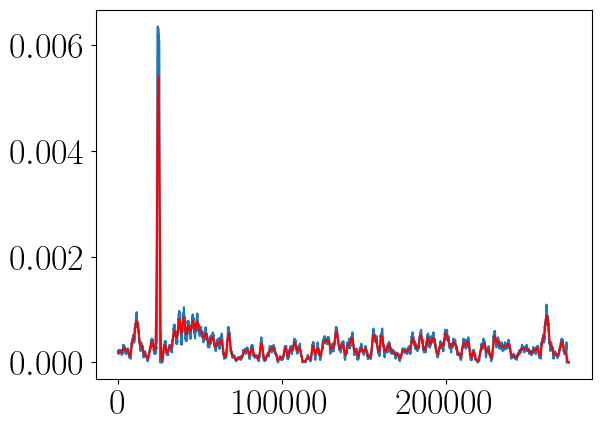

In [36]:
from scipy.ndimage import gaussian_filter1d
plt.plot(np.mean(total_f,0)[21])
plt.plot(gaussian_filter1d(np.mean(total_f,0)[21],500), color='red');


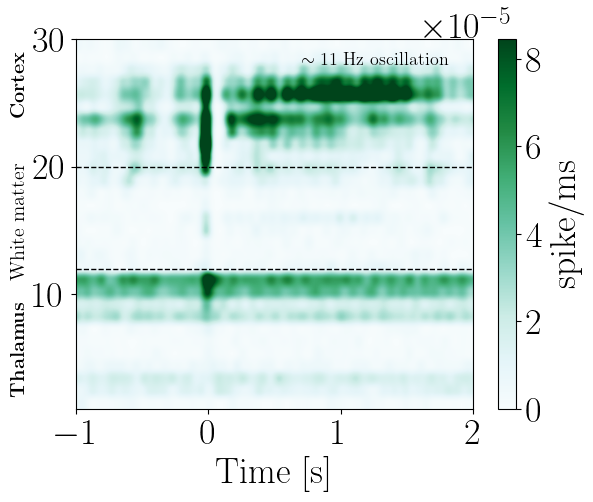

In [38]:
#path_n = 'C:/Users/Benedetta/Desktop/Criticality in barrel cortex/numpy files'
conv = 4e-5


ff = gaussian_filter1d(np.mean(total_f,0),500,axis = 1)
VMAX = np.std(ff*1000*conv)*5
im = plt.imshow(ff*1000*conv,
           extent=[0*conv -1, total_f[0].shape[1]*conv-1, 1, 30],
           aspect='auto',origin='lower', cmap='BuGn',vmax = VMAX)

plt.colorbar(label = 'spike/ms');
plt.hlines(12,-1,10,color ='black', linestyle ='--', lw =1)
plt.hlines(20,-1,10,color ='black', linestyle ='--', lw = 1)
plt.xlabel('Time [s]')
plt.text(0.7, 28,r'$\sim 11$ Hz oscillation', fontsize = 13)
plt.xlim(-1,2);

plt.ylabel(r'\textbf{Thalamus} \hspace{0.2cm} White matter \hspace{0.8cm} \textbf{Cortex}', fontsize = 14.5);
#plt.savefig(os.path.join(path_figures, 'oscillMUA.jpg'), dpi = 300, bbox_inches ='tight')

In [39]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 18
import numpy as np
import matplotlib.pyplot as plt
import mat73
import scipy.signal as ss
from mpl_toolkits.axes_grid1 import make_axes_locatable
import os
from scipy import signal

In [40]:
plt.rcParams['text.usetex'] =True
plt.rcParams['font.family'] = 'serif',
plt.rcParams['font.serif'] =  'Computer Modern'

In [41]:
import numpy as np

variables = list(globals().keys())

for var in variables:
    
    if isinstance(globals()[var], (list, np.ndarray)):
        if (var != 'total_f'):
            print(f"deleting: {var}")
            del globals()[var]

deleting: _ih
deleting: _dh
deleting: In
deleting: f
deleting: ff


In [22]:
local_data_path = "C:/Users/Benedetta/Downloads/Barrel+Talamo/Barrel+Talamo/"

In [6]:
#import os
#os.chdir(local_data_path)

In [133]:
whos

Variable          Type        Data/Info
---------------------------------------
compute_indexes   function    <function compute_indexes at 0x000001A73E2CB790>
file              str         Piezo_220131_114858.mat
filter_chunk      function    <function filter_chunk at 0x000001A72FED81F0>
get_chunk         function    <function get_chunk at 0x000001A73D67DEE0>
get_filters       function    <function get_filters at 0x000001A73DA8D5E0>
h5py              module      <module 'h5py' from 'C:\\<...>ages\\h5py\\__init__.py'>
np                module      <module 'numpy' from 'C:\<...>ges\\numpy\\__init__.py'>
open_file         function    <function open_file at 0x000001A73DBBC5E0>
os                module      <module 'os' from 'C:\\Us<...>\\anaconda3\\lib\\os.py'>
process_file      function    <function process_file at 0x000001A72FED8040>
ss                module      <module 'scipy.signal' fr<...>py\\signal\\__init__.py'>
total_f           ndarray     58x30x150000: 261000000 elems, type `flo

In [4]:
cd new_data_thalamus/

D:\new_data_thalamus


In [50]:
import h5py
import os
import numpy as np
import scipy.signal as ss

# =========================
# LOAD FILE (HDF5)
# =========================

def open_file(filepath):
    f = h5py.File(filepath, 'r')
    data = f['amplifier_data']
    #print(data.shape)
    print(f['adc_data'].shape)
    stim = np.array(f['adc_data'])[:,0]
    #print(stim)
    return f, data, stim

def compute_indexes(stim):
    indexes = (np.where(stim > 1.5)[0])[
        np.where(np.diff(np.where(stim > 1.5)[0]) > 1)
    ]
    indexes = np.array(
        indexes.tolist() +
        [int(indexes[-1] + np.diff(indexes)[-1])]
    ) - 125
    return indexes

# =========================
# FILTER DESIGN
# =========================

def get_filters(fs):
    nyq = 0.5 * fs
    
    # LFP band
    b_lfp, a_lfp = ss.butter(2, [0.1/nyq, 50/nyq], btype="bandpass")
    
    # Notch
    b_notch, a_notch = ss.iirnotch(100, 30, fs)
    
    return (b_lfp, a_lfp), (b_notch, a_notch)


# =========================
# CHUNK EXTRACTION
# =========================

def get_chunk(data_h5, start, stop, nchan):

    chunk = np.array(data_h5[start:stop,:nchan], dtype=np.float32)
    return chunk


# =========================
# FILTERING
# =========================

def filter_chunk(chunk, filters, thalamus=True):
    (b_lfp, a_lfp), (b_notch, a_notch) = filters
    #print(chunk.shape)
    sig = ss.filtfilt(b_lfp, a_lfp, chunk, axis=0)
    del chunk
    if thalamus:
        sig = ss.filtfilt(b_notch, a_notch, sig, axis=0)
    
    return sig


# =========================
# MAIN PIPELINE
# =========================

def process_file(filepath, thalamus=True, fs=25000, T=10):

    f, data, stim = open_file(filepath)
    indexes = compute_indexes(stim)

    filters = get_filters(fs)

    pre  = int(fs * 1)   # 1 sec before
    post = int(fs * T)   # 10 sec after

    nchan = 30 if thalamus else 27

    trials = []
    #print(len(indexes))
    for idx in indexes[1:-1]:

        start = idx - pre
        stop  = idx + post


        # === CHUNK LOAD ===
        chunk = get_chunk(data, start, stop, nchan)

        # === FILTER ===
        sig = filter_chunk(chunk, filters, thalamus)
        #print(sig.shape)
        trials.append(ss.decimate(sig,10,axis = 0))

    #f.close()
    del sig
    return np.array(trials)

file = os.listdir()[2]   # scegli file
lfpTrials = process_file(file, thalamus=True, T=5)

(7500032, 2)


In [53]:

downsampled= np.transpose(lfpTrials,(0,2,1))
downsampled.shape

NameError: name 'lfpTrials' is not defined

In [ ]:
#downsampled = ss.decimate(lfpTrials,10,axis = 2)
#downsampled.shape

In [54]:
downsampled.shape[2]/2500

6.0

In [52]:
del lfpTrials

In [55]:

import emd
from scipy import signal

fac = 10
final = []
sample_rate=int(25000/fac)
post = 3
ch_cort = np.array([15,16,17,18,19]) + 8
for ch in ch_cort:
    for tr in range(downsampled.shape[0]):
        x = downsampled[tr,ch,sample_rate:sample_rate*post]
        t = np.arange(0,len(x),1)/sample_rate
        num = int(len(x)/sample_rate)
        ii = 30 ##attenzione
        imf = emd.sift.mask_sift(x, max_imfs=9, mask_freqs= ii/sample_rate, ret_mask_freq=True)
        IP, IF, IA = emd.spectra.frequency_transform(imf[0], sample_rate, 'nht')
        freq_range = (0, 45, 64)
        hht_f, spec = emd.spectra.hilberthuang(IF, IA, freq_range, scaling='density', sum_imfs=False)
        final.append(spec)
        
final = np.asarray(final)

In [56]:

import emd
from scipy import signal

fac = 10
final_th = []
sample_rate=int(25000/fac)
post = 3

for ch in [5,6,7,8,9,10]:
    for tr in range(downsampled.shape[0]):
        x = downsampled[tr,ch,sample_rate:sample_rate*post]
        t = np.arange(0,len(x),1)/sample_rate
        num = int(len(x)/sample_rate)
        ii = 30 
        imf = emd.sift.mask_sift(x, max_imfs=9, mask_freqs= ii/sample_rate, ret_mask_freq=True)
        IP, IF, IA = emd.spectra.frequency_transform(imf[0], sample_rate, 'nht')
        freq_range = (0, 45, 64)
        hht_f, spec = emd.spectra.hilberthuang(IF, IA, freq_range, scaling='density', sum_imfs=False)
        final_th.append(spec)
        
final_th = np.asarray(final_th)



In [48]:
import warnings
warnings.filterwarnings('ignore')

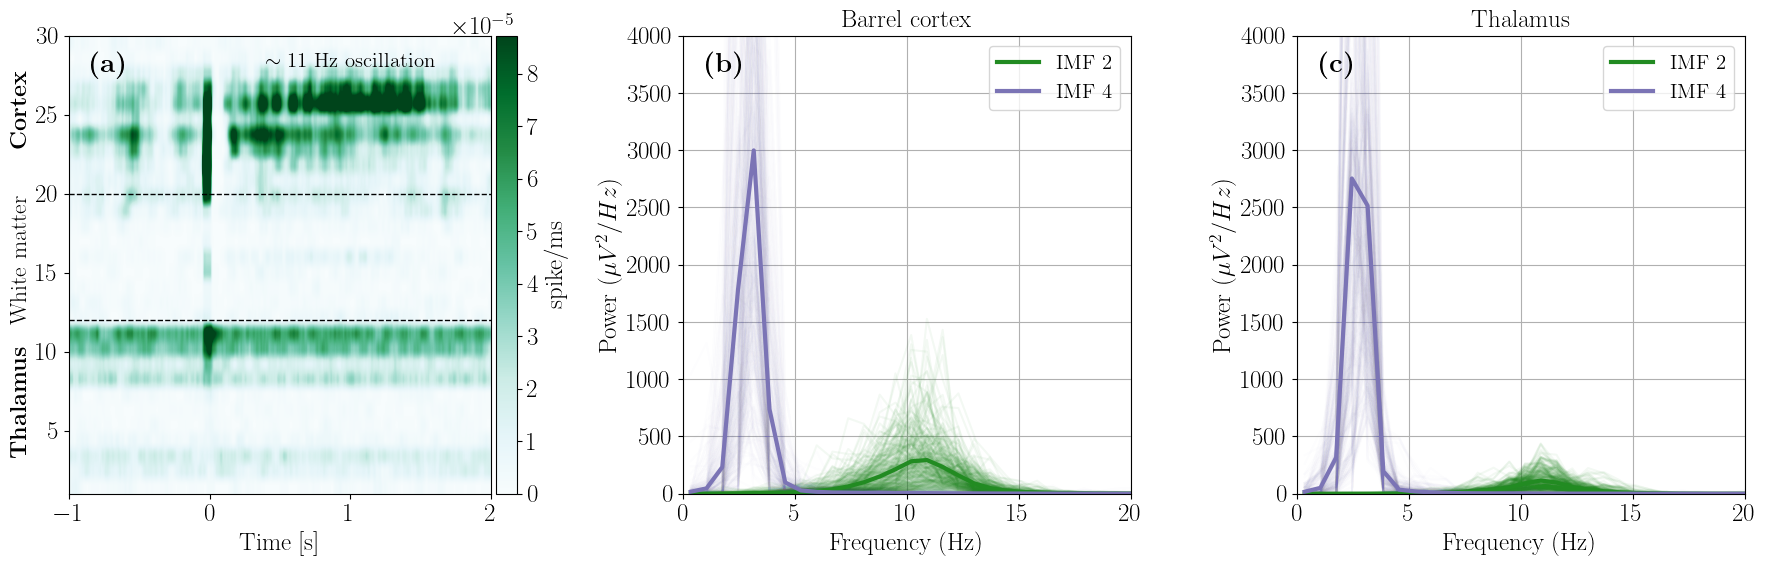

In [58]:
from matplotlib import cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt

fig,ax = plt.subplots(1,3,figsize = (18,6))

## nrat = 3

conv = 4e-5

#fir = np.load(os.path.join(path_n,'fir_thalamus_soglia_4.npy'))*coef*timebin*conv*1000


ff = np.mean(total_f,0)
VMAX = np.std(ff*1000*conv)*5
im = ax[0].imshow(np.mean(total_f,0)*1000*conv,
           extent=[0*conv -1, total_f[0].shape[1]*conv-1, 1, 30],
           aspect='auto',origin='lower', cmap='BuGn',vmax = VMAX)



ax[0].hlines(12,-1,10,color ='black', linestyle ='--', lw =1)
ax[0].hlines(20,-1,10,color ='black', linestyle ='--', lw = 1)
ax[0].set_xlabel('Time [s]')
ax[0].text(0.4, 28,r'$\sim 11$ Hz oscillation', fontsize = 15)
ax[0].set_xlim(-1,2);

divider = make_axes_locatable(ax[0])
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im, cax=cax,label = 'spike/ms');
ax[0].set_ylabel(r'\textbf{Thalamus} \hspace{0.2cm} White matter \hspace{0.8cm} \textbf{Cortex}', fontsize = 17);




ff = np.mean(final[:,:],0)

ax[1].plot(hht_f,final[:,:,1].T, color ='forestgreen', alpha = 0.05, );
ax[1].plot(hht_f,final[:,:,3].T, color =cm.get_cmap('Purples')(0.65), alpha = 0.01, );
ax[1].plot(hht_f, ff[:,1], lw = 3,color ='forestgreen',label = "IMF 2") 
ax[1].plot(hht_f, ff[:,3], lw = 3,color =cm.get_cmap('Purples')(0.65),label = "IMF 4")
ax[1].grid(True)
ax[1].set_xlim(0, 50)
ax[1].legend(fontsize = 15)
ax[1].set_xlabel('Frequency (Hz)');
ax[1].set_ylabel(f'Power ($\mu V^2/Hz$)');
#plt.yscale('log')
ax[1].set_ylim(0,4000)
ax[1].set_xlim(0,20)

ax[1].set_title('Barrel cortex',fontsize = 18)


## nrat = 3
ff = np.mean(final_th[:,:],0)

ax[2].plot(hht_f,final_th[:,:,1].T, color ='forestgreen', alpha = 0.05, );
ax[2].plot(hht_f,final_th[:,:,3].T, color =cm.get_cmap('Purples')(0.65), alpha = 0.01, );
ax[2].plot(hht_f, ff[:,1], lw = 3,color ='forestgreen',label = "IMF 2")
ax[2].plot(hht_f, ff[:,3], lw = 3,color =cm.get_cmap('Purples')(0.65),label = "IMF 4")
ax[2].grid(True)
ax[2].set_xlim(0, 50)
ax[2].legend(fontsize = 15)
ax[2].set_xlabel('Frequency (Hz)');
ax[2].set_ylabel(f'Power ($\mu V^2/Hz$)');
#plt.yscale('log')
ax[2].set_ylim(0,4000)
ax[2].set_xlim(0,20)
ax[2].set_title('Thalamus', fontsize = 18)



ax[0].annotate('\\textbf{(a)}', size = 20,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(0.05,0.92), textcoords='axes fraction')

ax[1].annotate('\\textbf{(b)}', size = 20,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(0.05,0.92), textcoords='axes fraction')
ax[2].annotate('\\textbf{(c)}', size = 20,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(0.05,0.92), textcoords='axes fraction')


plt.tight_layout();
#plt.savefig(path +"Thalamus/Paper Figures/Figura_4_final.jpg", bbox_inches = 'tight', dpi = 300 )